In [185]:
from sklearn.linear_model import LinearRegression
import pandas as pd

In [198]:
%run src/common_functions.py

# Linear Regression

Linear Regression is one of the simplest and most fundamental forms of Machine Learning and has existed for centuries. The goal is to find a linear function that describes the relationship between a dependent variable $y$ and one or more independent variables (features) $x_i$, which can then be used to predict new values.

Hence, Linear Regression is a supervised Machine Learning technique that is particularly useful when the relationship between the target variable $y$ and its features can be reasonably approximated by a linear function.

### Single-Parameter Linear Regression

The simplest form of Linear Regression uses a single feature $x$ and is expressed as

$$
\hat{y} = wx + b
$$

where $w$ is the parameter that determines the slope of the line and $b$ is the intercept.

The same model can also be written using the more general coefficient notation:

$$
\hat{y} = \beta_0 + \beta_1 x_1
$$

Here, $\beta_0$ is the intercept and $\beta_1$ is the coefficient associated with the feature $x_1$.

The hat over $\hat{y}$ indicates that this is the model's prediction, rather than the actual observed value $y$.

For a single feature, Linear Regression can therefore be visualized as fitting a straight line through a set of data points in two-dimensional space.


We'll use some arbitrary data to best illustrate Linear Regression on a few selected datapoints.

In [170]:
data = pd.DataFrame(
    {
        "x_1": [2, 4, 8],
        "x_2": [1, 3, 5],
        "x_3": [10, 20, 30],
        "y":   [4, 8, 16]
    }
)

In [71]:
%run linear_regression_single.py

Plotting the data reveals a clear linear relationship between $x$ and $y$. To begin, we will consider only a single feature, $x_1$ and therefore use the simple linear regression model

$$
\hat{y} = wx_1 + b
$$

This allows us to first examine how the parameters $w$ and $b$ are optimized using Gradient Descent before extending the model to multiple features.

It becomes obvious that the optimal solution solution would be $y = 2x$

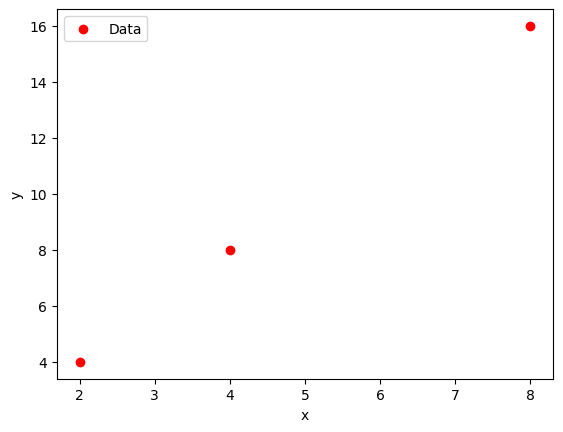

In [201]:
X = data["x_1"]
y = data["y"]

plot_data(X, y)

### Optimization function

The logic translates well from our previous example with $f(x) = x^2$. Here, we will optimize a different function.

A standard loss function that quantifies the errors, or residuals, between the actual datapoint values and the predicted values from our model is the Mean Squared Error (MSE):

$$

MSE(w, b) = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y_i})^2 = \frac{1}{n} \sum_{i=1}^n (y_i - (wx_{i,1} + b))^2

$$

where $y$ is the true value $f(x)$ and $\hat{y}$ is the model's prediction for the same $x$.

As we need to modify the parameters $b$ and $w$, we have to use partial derivatives of the MSE function. We can derive these partial derivatives using the chain rule of calculus.

$$
\frac{\partial MSE}{\partial b}(w,b) = \frac{1}{n} \sum_{i=1}^n 2(y_i - (wx_{1,i} + b)) * \frac{\partial}{\partial b} [y_i - (wx_{1,i} + b)] = \frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b)) * \frac{\partial}{\partial b} [y_i - wx_{1,i} - b] = \frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b)) * -1 = -\frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b))
$$

$$
\frac{\partial MSE}{\partial w}(w,b) = \frac{1}{n} \sum_{i=1}^n 2(y_i - (wx_{1,i} + b)) * \frac{\partial}{\partial w} [y_i - (wx_{1,i} + b)] = \frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b)) * \frac{\partial}{\partial w} [y_i - wx_{1,i} - b] = \frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b)) * -x_{1,i} = -\frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b))x_{1,i}
$$

Hence, when updating $b$, we will use $\frac{\partial MSE}{\partial b}$, and when updating $w$, we will use $\frac{\partial MSE}{\partial w}$.

Everything else stays the same, and we will update the two parameters according to the general Gradient Descent formula:

$$
x_{n+1} = x_n - \eta\nabla f(x_n)
$$

but for $b$:

$$
b_{n+1} = b_n - \eta \frac{\partial MSE}{\partial b}(w,b)
$$

and $w$:

$$
w_{n+1} = w_n - \eta \frac{\partial MSE}{\partial w}(w,b)
$$


For our example data, computing $w$ and $b$ using GD with a learning rate of $0.01$ and a max. of $500$ iterations, we get

$$
\hat{w} \approx 1.99, \hat{b} \approx 0.04
$$

which is already arbitrarly close to the optimal parameter values of $w = 2$, $b = 0$.

In [202]:
w_hat, b_hat = linear_regression_single(X, y, learning_rate=0.01, max_iters=500, tol=1e-6)

w_hat, b_hat

(np.float64(1.9937118366611004), np.float64(0.03743769780978872))

Plotting each individual update value of both $w$ and $b$ reveals their convergance towards both optimal values respectively.

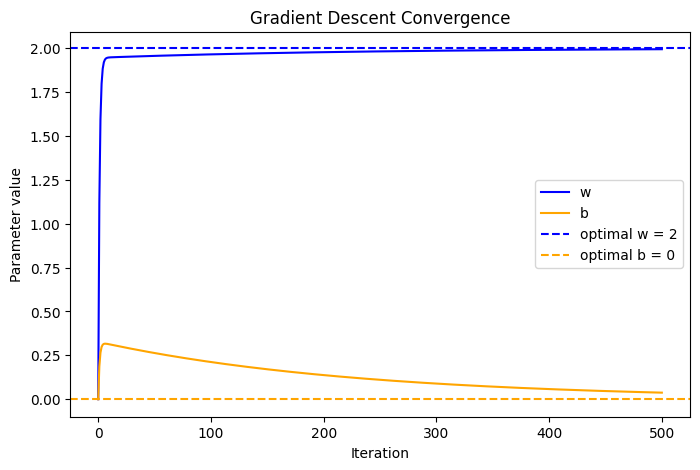

In [256]:
w_vals, b_vals = linear_regression_single(X, y, learning_rate=0.01, max_iters=500, tol=1e-6, history=True)

plot_optimal_parameters(w, b, optimal_w=2, optimal_b=0)

This plot illustrates how Gradient Descent iteratively adjusts the model parameters, gradually moving the linear function toward the configuration that minimizes the loss, i.e., the overall distance between the predictions and the actual data points.

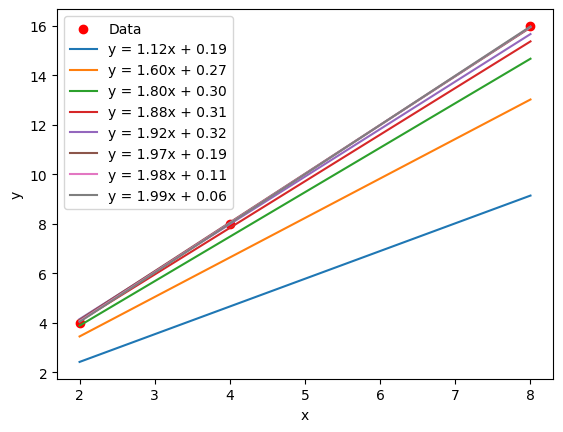

In [257]:
plot_gradient_progression_lr(X, y, w_vals, b_vals)

In [63]:
%run linear_regression

### Multivariate Linear Regression

Until now, we have only looked at single-feature Linear Regression, approximating the value of one parameter $w$.

However, Linear Regression can also be applied to problems with multiple features or regressors $w_i$ with $|w| = m$, taking the form of

$$
\hat{y} = w_1x_1 + w_2x_2 + \dots + w_mx_m + b = b + \sum_{i=1}^m w_ix_i
$$

or equivalently

$$
\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \dots + \beta_mx_m = \beta_0 + \sum_{i=1}^m \beta_ix_i
$$

where $n$ is the total number of features/ regressors and each $w_i$ or $\beta_i$ represents the coefficient with feature $x_i$.

Each coefficient determines how strongly its corresponding feature contributes to the prediction, while holding other features constant.

Still, the same logic of Gradient Descent can be applied. But instead of just increasing the number of derivates of MSE by the number of new parameters $w_i$, we can use vectors and matrix multiplication for efficient computations.

We can also use vector notation :

$$
\hat{y} = \mathbf{x}^T\mathbf{w}+b
$$

with 
$$
\mathbf{x} = \begin{bmatrix} x_1 \\ \dots \\ x_m \end{bmatrix}
$$


$$
\mathbf{w} = \begin{bmatrix} w_1 \\ \dots \\ w_m \end{bmatrix}
$$

where $\mathbf{x} \in \R^{1 \times m}$ denotes the feature values for a single observation, $\mathbf{w} \in \R^{1 \times m}$ is the parameter vector for all coefficients $w_i$.

For matrix multiplication, we need to transpose $\mathbf{x}$ s.t the number of columns of $\mathbf{x}$ equals the number of rows of $\mathbf{w}$, as we need a resulting scalar value for $\hat{y}$ (one value for our prediction).

Hence

$$
\hat{y} = x^Tw+b = \begin{bmatrix} x_1 \dots x_m \end{bmatrix} \begin{bmatrix} w_1 \\ \dots \\ w_m \end{bmatrix} + b = x_1w_1 + \dots + x_mw_m + b = b + \sum_{i=1}^m x_iw_i
$$

We could just use this equation and iterate over all datapoints, calculting everything over and over again for different feature values.

However, using matrix notation for $\mathbf{x}$, we can immediately store all datapoints simultaneously and perform the same calculations all 'at once' (as libraries are heavily optimized towards vectorization and matrix multiplication).

Therefore, the final equation we will work with is denoted as

$$
\mathbf{\hat{y}} = \mathbf{X}\mathbf{w} + b
$$

where 

$$
\mathbf{X} = 
\begin{bmatrix}
  x_{1,1} & \dots & x_{1,m} \\
  \dots & \dots & \dots \\
  x_{n,1} & \dots & x_{n,m}
\end{bmatrix}
$$

with $\mathbf{X} \in \R^{m \times n}$, $\mathbf{w} \in \R^{1 \times m}$ and $b \in \R$.

Therefore,

$$
\mathbf{\hat{y}} = \mathbf{X}\mathbf{w} + b = \begin{bmatrix} x_{1,1}w_1 + \dots + x_{1,m}w_m + b \\ \dots \\  x_{n,1}w_1 + \dots + x_{n,m}w_m + b \end{bmatrix}
$$

with $\mathbf{\hat{y}} \in \R^{1 \times n}$.

But we still need our loss function and its derivative, the gradient, to calculate the update steps for gradient descent.

Hence we'll partially derive the Mean Squared Error (MSE) for both $w$ and $b$.

We define for a single row and per feature value:
$$
L_{w,b} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y_i})^2 =  \frac{1}{n} \sum_{i=1}^n (y_i - (wx_{1,i}+b))^2
$$

and therefore
$$
\nabla L_b = \frac{1}{n} \sum_{i=1}^n 2(y_i - (wx_{1,i} + b)) * \frac{\partial}{\partial b} [y_i - (wx_{1,i} + b)] = \frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b)) * \frac{\partial}{\partial b} [y_i - wx_{1,i} - b] = \frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b)) * -1 = -\frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b))
$$

$$
\nabla L_w = \frac{1}{n} \sum_{i=1}^n 2(y_i - (wx_{1,i} + b)) * \frac{\partial}{\partial w} [y_i - (wx_{1,i} + b)] = \frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b)) * \frac{\partial}{\partial w} [y_i - wx_{1,i} - b] = \frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b)) * -x_{1,i} = -\frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b))x_{1,i}
$$

Lets define $\mathbf{y} \in \R^{1 \times n}$ as
$$
\mathbf{y} = \begin{bmatrix} y_1 \\ \dots \\ y_n \end{bmatrix}
$$

and the error as $\mathbf{e} \in \R^{1 \times n}$ as

$$
\mathbf{e} = \mathbf{y} - \mathbf{\hat{y}} = \mathbf{y} - (\mathbf{X}\mathbf{w}+b) = \begin{bmatrix} y_1 \\ \dots \\ y_n \end{bmatrix} - \begin{bmatrix} x_{1,1}w_1 + \dots + x_{1,m}w_m + b \\ \dots \\  x_{n,1}w_1 + \dots + x_{n,m}w_m + b \end{bmatrix} = \begin{bmatrix} y_1 - (x_{1,1}w_1 + \dots + x_{1,m}w_m + b) \\ \dots \\  y_n - (x_{n,1}w_1 + \dots + x_{n,m}w_m + b) \end{bmatrix} = \begin{bmatrix} e_1 \\ \dots \\ e_n \end{bmatrix}
$$

Now we can rewrite the derived gradients as

$$
\nabla L_w = -\frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b))x_{1,i} = -\frac{2}{n}X^Te
$$
$$
\nabla L_b = -\frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b)) = -\frac{2}{n}e
$$

We need to calcuate $X^Te$ instead of eX due to matrix multiplication rules as $X \in \R^{m \times n}$ and $e \in \R^{1 \times n}$.

Therefore,
$$
-\frac{2}{n}\mathbf{X}^T\mathbf{e} = -\frac{2}{n} 
\begin{bmatrix}
  x_{1,1} & \dots & x_{n,1} \\
  \dots & \dots & \dots \\
  x_{1,m} & \dots & x_{n,m}
\end{bmatrix} 
\begin{bmatrix} e_1 \\ \dots \\ e_n \end{bmatrix} = -\frac{2}{n} \begin{bmatrix} x_{1,1}e_1 + \dots + x_{n,1}e_n\\ \dots \\ x_{1,m}e_1 + \dots + x_{n,m}e_n \end{bmatrix} = \begin{bmatrix} -\frac{2}{n} (x_{1,1}e_1 + \dots + x_{n,1}e_n) \\ \dots \\ -\frac{2}{n} (x_{1,m}e_1 + \dots + x_{n,m}e_n) \end{bmatrix} = \begin{bmatrix} -\frac{2}{n} \sum_{i=1}^n x_{i,1}e_i \\ \dots \\ -\frac{2}{n} \sum_{i=1}^n x_{i,m}e_i \end{bmatrix}
$$

and 

$$
-\frac{2}{n}\mathbf{e} = -\frac{2}{n}\mathbf{1}^T\mathbf{e} = -\frac{2}{n} \begin{bmatrix} 1 & \dots & 1 \end{bmatrix} \begin{bmatrix} e_1 \\ \dots \\ e_n \end{bmatrix} = -\frac{2}{n} \begin{bmatrix} 1e_1 + \dots + 1e_n \end{bmatrix} = -\frac{2}{n} \sum_{i=1}^n e_i
$$

Those are our final gradient vector and scalar.

Plugging these into Gradient Descent yields

$$
b_{k+1} = b_k - \eta \nabla L_b = b_n - \eta (-\frac{2}{n} \sum_{i=1}^n e_i)
$$
$$
w_{k+1} = w_k - \eta \nabla L_w = \begin{bmatrix} w_1 \\ \dots \\ w_m \end{bmatrix} - \eta (\begin{bmatrix} -\frac{2}{n} \sum_{i=1}^n x_{i,1}e_i \\ \dots \\ -\frac{2}{n} \sum_{i=1}^n x_{i,m}e_i \end{bmatrix})
$$

In [174]:
X = data[["x_1", "x_2"]]
y = data["y"]

In [64]:
res = linear_regression(X, y, learning_rate=0.01, max_iters=500, tol=1e-6)
res

{'b': np.float64(0.043099083588761355), 'w_i': array([1.69342532, 0.46456003])}

In [197]:
X = data[["x_1", "x_2", "x_3"]]
y = data["y"]


res = linear_regression(X, y, learning_rate=0.001, max_iters=500_000, tol=1e-10)
print(res)

sklearn_lr = LinearRegression()
sklearn_lr.fit(X, y)

sklearn_lr.intercept_, sklearn_lr.coef_

{'b': np.float64(-5.144283709266459e-10), 'w_i': array([2.00000000e+00, 5.27721556e-10, 6.64823148e-11])}


(np.float64(-3.552713678800501e-15),
 array([2.00000000e+00, 7.37955645e-17, 3.68977823e-16]))